# Math 742: Mathematical Statistics
## Exam #1 - Out of Class Portion
## David Cortes
### February 17, 2026

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# For consistency, use the following seed value: 02112026. 
# Do this at the beginning and do not reset it at any
# point during the exam.
np.random.seed(2112026)

##### [Yes] I had read and understand the exam integrety statement

#### Problem 6 (10 points)
##### Monte Carlo and Inequalities


In [52]:
# Part (a)
# Estimate E[X], E[X^2], and (E[X])^2 using 10^6 draws

# number of simulated draws
n = 10**6

# draw n samples from Exponential(1)
# numpy uses scale = 1/lambda, so scale = 1
X = np.random.exponential(scale=1.0, size=n)

# estimate E[X]
EX_hat = np.mean(X)

# estimate E[X^2]
EX2_hat = np.mean(X**2)

# compute (E[X])^2 from our estimate
EX_sq_hat = EX_hat**2

# print results
print("Part (a): Monte Carlo estimates with n = 10^6 draws")
print("\n")
print(f"  E[X]     estimate: {EX_hat:.6f}   (true value: 1)")
print(f"  E[X^2]   estimate: {EX2_hat:.6f}   (true value: 2)")
print(f"  (E[X])^2 estimate: {EX_sq_hat:.6f}   (true value: 1)")

Part (a): Monte Carlo estimates with n = 10^6 draws


  E[X]     estimate: 1.000461   (true value: 1)
  E[X^2]   estimate: 2.003294   (true value: 2)
  (E[X])^2 estimate: 1.000922   (true value: 1)


In [53]:
# Problem 6, Part (b)
# Verify Jensen's inequality: (E[X])^2 <= E[X^2]

print("Part (b): Jensen's Inequality for phi(x) = x^2")
print("\n")

# from our estimates in part (a):
print(f"  (E[X])^2 = {EX_sq_hat:.6f}")
print(f"  E[X^2]   = {EX2_hat:.6f}")

# check the inequality
if EX_sq_hat <= EX2_hat:
    print("  Jensen's inequality holds: (E[X])^2 <= E[X^2]")
else:
    print("  Jensen's inequality NOT satisfied (unexpected)")


# the gap is the variance
gap = EX2_hat - EX_sq_hat
print(f"  Gap = E[X^2] - (E[X])^2 = {gap:.6f}")
print(f"  This gap estimates Var(X), whose true value is 1.")

Part (b): Jensen's Inequality for phi(x) = x^2


  (E[X])^2 = 1.000922
  E[X^2]   = 2.003294
  Jensen's inequality holds: (E[X])^2 <= E[X^2]
  Gap = E[X^2] - (E[X])^2 = 1.002371
  This gap estimates Var(X), whose true value is 1.


In [54]:
# Part (c)
# Estimate P(|X - E[X]| > 2) and compare with Chebyshev

# true mean
mu = 1.0

# Monte Carlo estimate of the probability
# count how many draws satisfy |X_i - 1| > 2
count = np.sum(np.abs(X - mu) > 2)
prob_mc = count / n

# exact value: P(X > 3) = e^{-3}
prob_exact = np.exp(-3)

# Chebyshev bound: sigma^2 / k^2 = 1 / 4
sigma2 = 1.0
k = 2.0
chebyshev_bound = sigma2 / k**2

print("Part (c): P(|X - E[X]| > 2)")
print("\n")
print(f"  Monte Carlo estimate:  {prob_mc:.6f}")
print(f"  Exact value (e^-3):    {prob_exact:.6f}")
print(f"  Chebyshev upper bound: {chebyshev_bound:.6f}")

Part (c): P(|X - E[X]| > 2)


  Monte Carlo estimate:  0.049618
  Exact value (e^-3):    0.049787
  Chebyshev upper bound: 0.250000


#### Problem 7 (10 points)
##### Transformations and Sampling Distributions

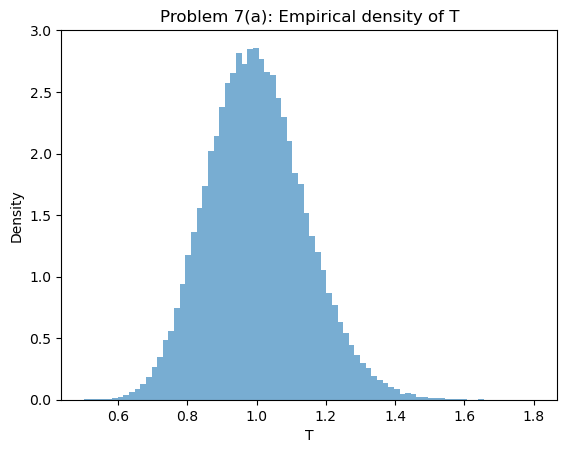

In [55]:
# Part (a)
n7 = 50
B7 = 100000
samples7 = np.random.exponential(scale=1.0, size=(B7, n7))
T_vals = samples7.mean(axis=1)

plt.hist(T_vals, bins=80, density=True, alpha=0.6)
plt.xlabel('T')
plt.ylabel('Density')
plt.title('Problem 7(a): Empirical density of T')
plt.show()

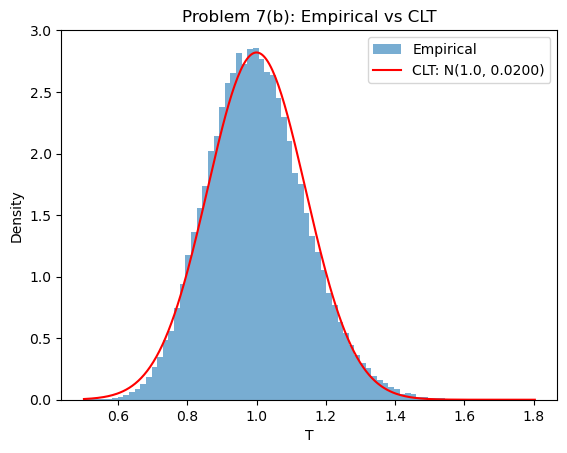

CLT predicts T ~ N(mu=1.0, sigma^2=0.0200)
  mean = 1.0,  std dev = 0.141421


In [56]:
# Part (b)
from scipy.stats import norm

mu_T = 1.0
sigma_T = 1.0 / np.sqrt(n7)

t_grid = np.linspace(T_vals.min(), T_vals.max(), 300)
normal_pdf = norm.pdf(t_grid, loc=mu_T, scale=sigma_T)

plt.hist(T_vals, bins=80, density=True, alpha=0.6, label='Empirical')
plt.plot(t_grid, normal_pdf, 'r-', label=f'CLT: N({mu_T}, {sigma_T**2:.4f})')
plt.xlabel('T')
plt.ylabel('Density')
plt.title('Problem 7(b): Empirical vs CLT')
plt.legend()
plt.show()

print(f"CLT predicts T ~ N(mu={mu_T}, sigma^2={sigma_T**2:.4f})")
print(f"  mean = {mu_T},  std dev = {sigma_T:.6f}")

In [57]:
# Part (c)
# Compute empirical bias and variance of T

# empirical mean of T across all replications
T_mean = np.mean(T_vals)

# empirical bias = mean(T) - true mu
bias_emp = T_mean - 1.0

# empirical variance (use ddof=1 for sample variance)
var_emp = np.var(T_vals, ddof=1)

# theoretical values
bias_true = 0.0
var_true_T = 1.0 / n7   # sigma^2 / n = 1/50 = 0.02

print("Part (c): Empirical bias and variance of T")
print("\n")
print(f"{'Quantity':<30} {'Empirical':>12} {'Theoretical':>12}")
print("\n")
print(f"{'E[T]':<30} {T_mean:>12.6f} {1.0:>12.6f}")
print(f"{'Bias(T) = E[T] - mu':<30} {bias_emp:>12.6f} {bias_true:>12.6f}")
print(f"{'Var(T) = sigma^2 / n':<30} {var_emp:>12.6f} {var_true_T:>12.6f}")

Part (c): Empirical bias and variance of T


Quantity                          Empirical  Theoretical


E[T]                               1.000825     1.000000
Bias(T) = E[T] - mu                0.000825     0.000000
Var(T) = sigma^2 / n               0.019971     0.020000


#### Problem 8 (10 points)
##### Likelihood, MLE, and Invariance

In [58]:
# Part (a)
# Simulate 10,000 datasets, compute MLE lambda_hat = X_bar

n8 = 50           # sample size
B8 = 10_000       # number of simulated datasets
lam_true = 3      # true lambda

# generate B8 x n8 matrix of Poisson(3) draws
samples8 = np.random.poisson(lam=lam_true, size=(B8, n8))

# MLE for each dataset: lambda_hat = sample mean
lam_hat = samples8.mean(axis=1)

print("Part (a): MLE for 10,000 Poisson(3) datasets (n=50)")
print("\n")
print(f"  First 10 MLEs: {np.round(lam_hat[:10], 4)}")
print(f"  Mean of MLEs:  {np.mean(lam_hat):.6f}  (true lambda = {lam_true})")

Part (a): MLE for 10,000 Poisson(3) datasets (n=50)


  First 10 MLEs: [3.36 3.04 3.14 2.86 3.04 3.2  3.16 3.06 2.68 2.82]
  Mean of MLEs:  2.997468  (true lambda = 3)


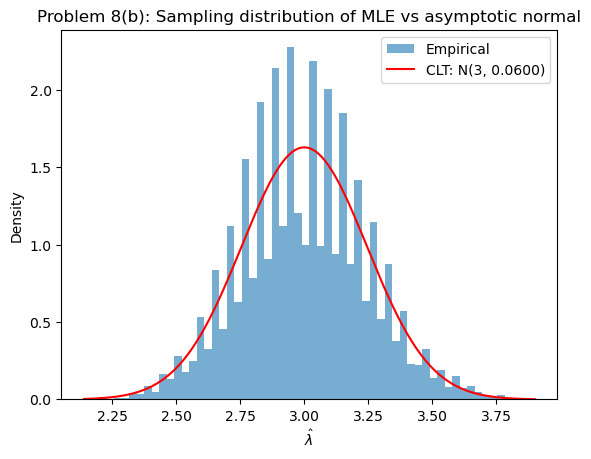

Asymptotic distribution: N(3, 0.0600)
  std dev = sqrt(lambda/n) = sqrt(3/50) = 0.244949


In [59]:
# Part (b)
mu_mle = lam_true
sigma_mle = np.sqrt(lam_true / n8)

x_grid = np.linspace(lam_hat.min(), lam_hat.max(), 300)
norm_pdf = norm.pdf(x_grid, loc=mu_mle, scale=sigma_mle)

plt.hist(lam_hat, bins=60, density=True, alpha=0.6, label='Empirical')
plt.plot(x_grid, norm_pdf, 'r-', label=f'CLT: N({mu_mle}, {sigma_mle**2:.4f})')
plt.xlabel('$\\hat{\\lambda}$')
plt.ylabel('Density')
plt.title('Problem 8(b): Sampling distribution of MLE vs asymptotic normal')
plt.legend()
plt.show()

print(f"Asymptotic distribution: N({mu_mle}, {sigma_mle**2:.4f})")
print(f"  std dev = sqrt(lambda/n) = sqrt(3/50) = {sigma_mle:.6f}")

In [60]:
# Part (c)
# Invariance: P(X=0)_hat = exp(-lambda_hat), estimate bias

# true P(X=0)
p0_true = np.exp(-lam_true)   # e^{-3}

# MLE of P(X=0) for each simulated dataset, by invariance
p0_hat = np.exp(-lam_hat)

# empirical mean of the estimator
p0_hat_mean = np.mean(p0_hat)

# estimated bias
bias_p0 = p0_hat_mean - p0_true

print("Part (c): Invariance-based MLE of P(X=0)")
print("\n")
print(f"  True P(X=0) = e^(-3) = {p0_true:.6f}")
print(f"  Mean of e^(-lambda_hat) across {B8} sims = {p0_hat_mean:.6f}")
print(f"  Estimated bias = E[e^(-lambda_hat)] - e^(-3) = {bias_p0:.6f}")
print()
if bias_p0 > 0:
    print(f"  The estimator has a small POSITIVE bias ({bias_p0:.6f}).")
else:
    print(f"  The estimator has a small NEGATIVE bias ({bias_p0:.6f}).")


Part (c): Invariance-based MLE of P(X=0)


  True P(X=0) = e^(-3) = 0.049787
  Mean of e^(-lambda_hat) across 10000 sims = 0.051402
  Estimated bias = E[e^(-lambda_hat)] - e^(-3) = 0.001615

  The estimator has a small POSITIVE bias (0.001615).
